In [1592]:
#from google.colab import files
#uploaded = files.upload()


In [1593]:
import pandas as pd
df1= pd.read_csv("../Webscraping/jumia_baby_products_20260201_010757.csv")
df2 = pd.read_csv("../Webscraping/tots_shoppe_products_20260201_024927.csv")
df3 = pd.read_csv("../Webscraping/peekaboo_products_20260220_103805.csv")
pos_sales_data = pd.read_csv("pos_cleaned_data.csv")

In [1594]:
df1.head()


,date,product_name,brand,seller_name,seller_id,current_price,original_price,discount_percentage,rating,reviews,product_url
0,2026-02-01 01:08:03,"Baby smart milk shaker, automatic milk shaker,...",Generic,Unknown,83275,1273.0,"KSh 2,010",37%,NaN,NaN,https://www.jumia.co.ke/generic-baby-smart-mil...
1,2026-02-01 01:08:08,NAN 1 Optipro 1 Infant Formula Milk Powder 400...,Nestle,Unknown,94314,2998.0,"KSh 4,500",33%,NaN,NaN,https://www.jumia.co.ke/nestle-nan-1-optipro-1...
2,2026-02-01 01:08:12,Kendamil Toddler milk stage 3 (12-36 Months),Kendamil,Unknown,204756,2499.0,"KSh 3,499",29%,NaN,NaN,https://www.jumia.co.ke/kendamil-kendamil-todd...
3,2026-02-01 01:08:16,Nan Optipro 1 Infant Formula Milk Powder 400g ...,Nestle Nutrition,Unknown,198351,2700.0,"KSh 3,000",10%,NaN,NaN,https://www.jumia.co.ke/nestle-nutrition-nan-o...
4,2026-02-01 01:08:21,NAN Optipro 1 Infant Formula Milk Powder 400g...,Nestle,Unknown,79855,2799.0,"KSh 4,500",38%,NaN,NaN,https://www.jumia.co.ke/nestle-nan-optipro-1-i...


In [1595]:
df2.head()

,product_id,variant_id,product_name,variant_name,brand,category,current_price,original_price,discount_amount,discount_percentage,has_discount,sku,scrape_date
0,9.351690e+12,4.810540e+13,"kendamil organic follow on milk, 6-12months, 800g",Default Title,tots shoppe kenya,baby formula,5500.0,NaN,0.0,0.0,0,NaN,01/02/2026
1,9.136920e+12,4.697690e+13,nannycare first infant milk formula- stage 1 (...,Default Title,tots shoppe kenya,baby formula,7000.0,NaN,0.0,0.0,0,NaN,01/02/2026
2,7.486810e+12,4.220610e+13,"kendamil follow on goat milk, 6-12months, 800g",Default Title,tots shoppe kenya,baby formula,7000.0,NaN,0.0,0.0,0,NaN,01/02/2026
3,8.909290e+12,4.624610e+13,aptamil comfort baby milk powder 800g (new),Default Title,tots shoppe kenya,baby formula,6000.0,NaN,0.0,0.0,0,NaN,01/02/2026
4,9.054040e+12,4.670200e+13,"kirkland signature baby wipes fragrance free, ...",Default Title,tots shoppe kenya,diapering and wipes,1500.0,NaN,0.0,0.0,0,NaN,01/02/2026


In [1596]:
df3.head()

,product_id,variant_id,product_name,variant_name,brand,category,current_price,original_price,discount_amount,discount_percentage,has_discount,sku,scrape_date
0,8.910000e+12,4.800000e+13,momcozy non-contact forehead and ear thermomet...,Default Title,momcozy,health & safety,4099,NaN,0,0.0,0,PB1129000020,20/02/2026
1,8.910000e+12,4.800000e+13,momcozy 57-inch u shaped cooling fabric pregna...,Default Title,momcozy,"feeding,health & safety",7799,NaN,0,0.0,0,PB1129000019,20/02/2026
2,8.910000e+12,4.800000e+13,momcozy maternity accessory j shaped maternity...,Default Title,momcozy,"feeding,health & safety",5199,NaN,0,0.0,0,PB1129000018,20/02/2026
3,8.910000e+12,4.800000e+13,momcozy multifunctional and adjustable nursing...,Default Title,momcozy,"feeding,health & safety",5399,NaN,0,0.0,0,PB1129000017,20/02/2026
4,8.910000e+12,4.800000e+13,momcozy ice lanolin-free soothing balm nipple ...,Default Title,momcozy,health & safety,1799,NaN,0,0.0,0,PB1129000016,20/02/2026


In [1597]:
import pandas as pd
import re
# Install rapidfuzz if not already installed
try:
    from rapidfuzz import fuzz
except ImportError:
    %pip install rapidfuzz
    from rapidfuzz import fuzz


# ==========================================================
# 1. LOAD DATA
# ==========================================================
#df1 = pd.read_csv("/content/tots_shoppe_products_20260201_024927.csv")
#df2 = pd.read_csv("/content/jumia_baby_products_20260201_010757.csv")
#df3 = pd.read_csv("/content/peekaboo_products_20260220_103805.csv")

df1["source"] = "totshoppe"
df2["source"] = "jumia"
df3["source"] = "peekaboo"

df = pd.concat([df1, df2, df3], ignore_index=True)

# ==========================================================
# 2. USER PRODUCT LIST
# ==========================================================

# Extract unique product names from pos_sales_data to update user_products
user_products = pos_sales_data['Product'].unique().tolist()


# ==========================================================
# 3. CLEAN FUNCTION
# ==========================================================
def clean_text(text):
    if isinstance(text, str):
        text = text.lower()
        text = text.replace('&', 'and')
        text = text.replace('(', '').replace(')', '')
        text = re.sub(r'\buk\b', '', text)

        # then normalize all separators (spaces and hyphens) to single space.
        text = re.sub(r'[^a-z0-9\s-]', '', text) # Keep hyphens
        text = re.sub(r'[\s-]+', ' ', text).strip() # Treat hyphens and spaces as delimiters
        text = re.sub(r'\s+', ' ', text).strip()
       # Space between letters and numbers
        text = re.sub(r'(?<=\d)([a-z]+)', r' \1', text)
        text = re.sub(r'([a-z]+)(?=\d)', r'\1 ', text)

       # Clean hyphens between numbers
        text = re.sub(r'(?<=\d)\s*[-\s]\s*(?=\d)', '-', text)
        text = re.sub(r'(?<!\d)-(?!\d)', '', text)


        # Remove potential duplicate 'stage X stage X' artifacts if they arise
        #text = re.sub(r'(stage\s+\d+)\s+\1', r'\1', text)

        return text
    return ""

df["clean_name"] = df["product_name"].apply(clean_text)
df["brand"] = df["brand"].apply(clean_text)
cleaned_user_products = [clean_text(p) for p in user_products]

# Create a mapping from cleaned user product names to original user product names
cleaned_to_original_user_product_map = {clean_text(p): p for p in user_products}

# ==============================
# 4. BRAND FILTER (FAST FIRST PASS)
# ==============================
brands = [
    'aptamil', 'nannycare', 'nanny care', 'nanny', 'cow and gate',
    'hipp', 'hip', 'hipp organic', 'kendamil',
    'little angels', 'mamia', 'waterwipes'
]

def brand_match(row): # Takes the entire row
    product_clean_name = row["clean_name"]
    # Apply clean_text to the brand column value for consistent cleaning
    cleaned_brand_column = clean_text(row.get("brand", ""))

    # Check if any listed brand is in the cleaned product name or in the cleaned brand column
    return any(b in product_clean_name for b in brands) or \
           any(b in cleaned_brand_column for b in brands)

df = df[df.apply(brand_match, axis=1)] # Apply to rows


# ==========================================================
# 5. STRICT STRUCTURED MATCHING (STAGE + WEIGHT LOCK)
# ==========================================================

threshold = 75

def extract_stage(text):
    match = re.search(r'stage\s*(\d)', text)
    if match:
        return match.group(1)
    # If written like "organic 1 first infant"
    match = re.search(r'\b(\d)\b', text)
    return match.group(1) if match else None

def extract_grams(text):
    match = re.search(r'(\d+)\s?g', text)
    return match.group(1) if match else None

matched_rows = []

for _, row in df.iterrows():
    comp_name = row["clean_name"]
    comp_brand = row["brand"]

    comp_stage = extract_stage(comp_name)
    comp_grams = extract_grams(comp_name)

    best_match = None
    highest_score = 0

    for user_clean in cleaned_user_products:

        user_stage = extract_stage(user_clean)
        user_grams = extract_grams(user_clean)

        # =========================================
        # ✅ STAGE LOCK (STRICT)
        # =========================================
        if user_stage and comp_stage:
            if user_stage != comp_stage:
                continue

        # =========================================
        # ✅ GRAM LOCK (STRICT)
        # =========================================
        if user_grams and comp_grams:
            if user_grams != comp_grams:
                continue

        # =========================================
        # ✅ BRAND LOCK
        # =========================================
        competitor_brands = {
            b for b in brands
            if b in comp_name or b in comp_brand
        }

        user_brands = {
            b for b in brands
            if b in user_clean
        }

        if competitor_brands and user_brands:
            if competitor_brands != user_brands:
                continue

        # =========================================
        # ✅ HYBRID FUZZY SCORE
        # =========================================
        score = (
            fuzz.token_set_ratio(user_clean, comp_name) * 0.7 +
            fuzz.partial_ratio(user_clean, comp_name) * 0.3
        )

        if score >= threshold and score > highest_score:
            highest_score = score
            best_match = user_clean

    if best_match:
        row_data = row.to_dict()
        row_data["matched_user_product_cleaned"] = best_match # ADDED THIS LINE
        row_data["matched_user_product_original"] = \
            cleaned_to_original_user_product_map[best_match]
        row_data["similarity_score"] = round(highest_score, 2)
        matched_rows.append(row_data)

matched_df = pd.DataFrame(matched_rows)

print(f"Total matched competitor products: {len(matched_df)}")



# Add the original user product name column
matched_df["matched_user_product_original"] = matched_df["matched_user_product_cleaned"].map(cleaned_to_original_user_product_map)

print(f"Total matched competitor products: {len(matched_df)}")

# ==========================================================
# 6. CLEAN PRICE COLUMNS
# ==========================================================
def clean_price(p):
    if isinstance(p, str):
        p = re.sub(r'[^0-9.]', '', p)
    return pd.to_numeric(p, errors="coerce")

for col in ["current_price", "original_price"]:
    if col in matched_df.columns:
        matched_df[col] = matched_df[col].apply(clean_price)

# ==========================================================
# 7. SELECT COMPETITOR PRICE INFO
# ==========================================================
columns_to_keep = [
    col for col in [
        "source",
        "matched_user_product_original", # New column for original user product name
        "product_name",
        "brand",
        "seller_name",
        "seller_id",
        "current_price",
        "original_price",
        "discount_percentage",
        "similarity_score"
    ] if col in matched_df.columns
]

competitor_price_df = matched_df[columns_to_keep]

# ==========================================================
# 8. REMOVE DUPLICATES
# ==========================================================
competitor_price_df = competitor_price_df.drop_duplicates(
    subset=["source", "product_name", "matched_user_product_original"]
)

competitor_price_df.head(50)

Total matched competitor products: 27
Total matched competitor products: 27


,source,matched_user_product_original,product_name,brand,seller_name,seller_id,current_price,original_price,discount_percentage,similarity_score
0,totshoppe,aptamil stage 1 first infant milk powder 800 g,APTAMIL1,aptamil,Unknown,146230.0,3800.0,5200.0,27%,98.24
1,totshoppe,cow and gate creamy porridge 4-6 months 125 g,"Creamy Porridge Baby Food Cereal, 4-6+ Months,...",cow and gate,Unknown,206788.0,1999.0,NaN,NaN,78.46
2,totshoppe,aptamil stage 2 follow on milk powder 800 g,Follow On Formula Milk Powder Stage 2 800g 6 -...,aptamil,Unknown,174225.0,5850.0,6500.0,10%,75.23
3,totshoppe,aptamil creamed porridge 4 month plus 125 g,Creamed Porridge 4-6months,aptamil,Unknown,220888.0,1999.0,NaN,NaN,78.76
4,totshoppe,hipp organic 1 first milk powder 800 g,HIPP ORGANIC 1,hip,Unknown,146230.0,5500.0,7000.0,21%,100.00
5,totshoppe,aptamil creamed banana 125 g,"Creamed Banana Porridge Baby Food Cereal, 4-6+...",aptamil,Unknown,220888.0,1999.0,NaN,NaN,79.26
6,totshoppe,cow and gate creamy porridge 4-6 months 125 g,"Creamy Porridge Baby Food Cereal, 4-6+ Months...",cow and gate,Unknown,146230.0,1500.0,2300.0,35%,78.46
7,totshoppe,aptamil stage 2 follow on milk powder 800 g,2 Follow On Baby Milk Powder,aptamil,Unknown,146230.0,3800.0,5200.0,27%,87.78
8,totshoppe,kendamil organic first infant milk 800 g,"Organic First Infant Milk, Stage 1",kendamil,Unknown,146230.0,5500.0,7000.0,21%,85.66
9,jumia,kendamil organic follow on milk 6-12 months 800 g,"kendamil organic follow on milk, 6-12months, 800g",tots shoppe kenya,NaN,NaN,5500.0,NaN,0.0,100.00


In [1598]:
df = competitor_price_df

In [1599]:
jumia_products = df[df['source'] == 'jumia']
print(f"Total identified products from Jumia: {len(jumia_products)}")
jumia_products.head(10)

Total identified products from Jumia: 11


,source,matched_user_product_original,product_name,brand,seller_name,seller_id,current_price,original_price,discount_percentage,similarity_score
9,jumia,kendamil organic follow on milk 6-12 months 800 g,"kendamil organic follow on milk, 6-12months, 800g",tots shoppe kenya,NaN,NaN,5500.0,NaN,0.0,100.00
10,jumia,kendamil organic follow on milk 6-12 months 800 g,"kendamil follow on goat milk, 6-12months, 800g",tots shoppe kenya,NaN,NaN,7000.0,NaN,0.0,91.59
11,jumia,kendamil organic first infant milk 800 g,kendamil organic first infant milk 800g,tots shoppe kenya,NaN,NaN,5500.0,NaN,0.0,100.00
12,jumia,aptamil stage 1 first infant milk powder 800 g,aptamil (uk) stage 1 first infant milk powder ...,tots shoppe kenya,NaN,NaN,3800.0,NaN,0.0,98.28
13,jumia,aptamil stage 2 follow on milk powder 800 g,aptamil (uk) stage 2 follow on milk powder 800g,tots shoppe kenya,NaN,NaN,3800.0,NaN,0.0,100.00
14,jumia,aptamil stage 3 toddler milk powder 800 g,"aptamil (uk) stage 3 toddler milk powder, 800g",tots shoppe kenya,NaN,NaN,3800.0,NaN,0.0,100.00
15,jumia,kendamil organic follow on milk 6-12 months 800 g,"kendamil organic toddler milk, 12+months, 800g",tots shoppe kenya,NaN,NaN,5500.0,NaN,0.0,84.25
16,jumia,waterwipes bathing and skin care sensitive new...,waterwipes baby wipes sensitive newborn skin- ...,tots shoppe kenya,NaN,NaN,1100.0,NaN,0.0,92.48
17,jumia,kendamil organic first infant milk 800 g,"kendamil classic first infant milk, 0-6months,...",tots shoppe kenya,NaN,NaN,5000.0,NaN,0.0,87.49
18,jumia,hipp organic 1 first milk powder 800 g,hipp organic anti reflux baby milk powder form...,tots shoppe kenya,NaN,NaN,6000.0,NaN,0.0,80.71


In [1600]:
jumia_products = df[df['source'] == 'totshoppe']
print(f"Total identified products from Jumai: {len(jumia_products)}")
jumia_products.head(12)

Total identified products from Jumai: 9


,source,matched_user_product_original,product_name,brand,seller_name,seller_id,current_price,original_price,discount_percentage,similarity_score
0,totshoppe,aptamil stage 1 first infant milk powder 800 g,APTAMIL1,aptamil,Unknown,146230.0,3800.0,5200.0,27%,98.24
1,totshoppe,cow and gate creamy porridge 4-6 months 125 g,"Creamy Porridge Baby Food Cereal, 4-6+ Months,...",cow and gate,Unknown,206788.0,1999.0,NaN,NaN,78.46
2,totshoppe,aptamil stage 2 follow on milk powder 800 g,Follow On Formula Milk Powder Stage 2 800g 6 -...,aptamil,Unknown,174225.0,5850.0,6500.0,10%,75.23
3,totshoppe,aptamil creamed porridge 4 month plus 125 g,Creamed Porridge 4-6months,aptamil,Unknown,220888.0,1999.0,NaN,NaN,78.76
4,totshoppe,hipp organic 1 first milk powder 800 g,HIPP ORGANIC 1,hip,Unknown,146230.0,5500.0,7000.0,21%,100.00
5,totshoppe,aptamil creamed banana 125 g,"Creamed Banana Porridge Baby Food Cereal, 4-6+...",aptamil,Unknown,220888.0,1999.0,NaN,NaN,79.26
6,totshoppe,cow and gate creamy porridge 4-6 months 125 g,"Creamy Porridge Baby Food Cereal, 4-6+ Months...",cow and gate,Unknown,146230.0,1500.0,2300.0,35%,78.46
7,totshoppe,aptamil stage 2 follow on milk powder 800 g,2 Follow On Baby Milk Powder,aptamil,Unknown,146230.0,3800.0,5200.0,27%,87.78
8,totshoppe,kendamil organic first infant milk 800 g,"Organic First Infant Milk, Stage 1",kendamil,Unknown,146230.0,5500.0,7000.0,21%,85.66


In [1601]:
jumia_products = df[df['source'] == 'peekaboo']
print(f"Total identified products from Jumai: {len(jumia_products)}")
jumia_products.head(10)

Total identified products from Jumai: 7


,source,matched_user_product_original,product_name,brand,seller_name,seller_id,current_price,original_price,discount_percentage,similarity_score
20,peekaboo,nannycare growing up milk goat milk based 3 fr...,nannycare growing up milk goat milk based 3 fr...,nannycare,NaN,NaN,9999.0,NaN,0.0,100.00
21,peekaboo,nannycare 2 follow on milk goat milk based fro...,nannycare follow on goat milk stage 2 900g ag...,nannycare,NaN,NaN,9999.0,NaN,0.0,79.76
22,peekaboo,nannycare 1 formula first infant goat milk 900...,nannycare 1 formula first infant goat milk n...,nannycare,NaN,NaN,9999.0,NaN,0.0,88.52
23,peekaboo,hipp organic 3 from 1 year onwards growing up ...,hipp organic 3 from 1 year onwards growing up ...,hipp organic,NaN,NaN,5799.0,NaN,0.0,100.00
24,peekaboo,hipp organic combiotic follow on milk 800 g,hipp organic combiotic formula follow on milk ...,hipp organic,NaN,NaN,5799.0,NaN,0.0,89.17
25,peekaboo,hipp organic 1 first milk powder 800 g,hipp organic 1 first milk powder formula 800g-...,hipp organic,NaN,NaN,5799.0,NaN,0.0,97.89
26,peekaboo,aptamil stage 1 first infant milk powder 800 g,aptamil nutribiotik stage 1 infant milk powde...,aptamil,NaN,NaN,3540.0,NaN,0.0,88.98


In [1602]:
df.head(50)

,source,matched_user_product_original,product_name,brand,seller_name,seller_id,current_price,original_price,discount_percentage,similarity_score
0,totshoppe,aptamil stage 1 first infant milk powder 800 g,APTAMIL1,aptamil,Unknown,146230.0,3800.0,5200.0,27%,98.24
1,totshoppe,cow and gate creamy porridge 4-6 months 125 g,"Creamy Porridge Baby Food Cereal, 4-6+ Months,...",cow and gate,Unknown,206788.0,1999.0,NaN,NaN,78.46
2,totshoppe,aptamil stage 2 follow on milk powder 800 g,Follow On Formula Milk Powder Stage 2 800g 6 -...,aptamil,Unknown,174225.0,5850.0,6500.0,10%,75.23
3,totshoppe,aptamil creamed porridge 4 month plus 125 g,Creamed Porridge 4-6months,aptamil,Unknown,220888.0,1999.0,NaN,NaN,78.76
4,totshoppe,hipp organic 1 first milk powder 800 g,HIPP ORGANIC 1,hip,Unknown,146230.0,5500.0,7000.0,21%,100.00
5,totshoppe,aptamil creamed banana 125 g,"Creamed Banana Porridge Baby Food Cereal, 4-6+...",aptamil,Unknown,220888.0,1999.0,NaN,NaN,79.26
6,totshoppe,cow and gate creamy porridge 4-6 months 125 g,"Creamy Porridge Baby Food Cereal, 4-6+ Months...",cow and gate,Unknown,146230.0,1500.0,2300.0,35%,78.46
7,totshoppe,aptamil stage 2 follow on milk powder 800 g,2 Follow On Baby Milk Powder,aptamil,Unknown,146230.0,3800.0,5200.0,27%,87.78
8,totshoppe,kendamil organic first infant milk 800 g,"Organic First Infant Milk, Stage 1",kendamil,Unknown,146230.0,5500.0,7000.0,21%,85.66
9,jumia,kendamil organic follow on milk 6-12 months 800 g,"kendamil organic follow on milk, 6-12months, 800g",tots shoppe kenya,NaN,NaN,5500.0,NaN,0.0,100.00


In [1603]:
jumia_products_df = df[df['source'] == 'jumia']
jumia_min_prices = jumia_products_df.groupby('matched_user_product_original')['current_price'].min().reset_index(name='jumia_min_price')

totshoppe_products_df = df[df['source'] == 'totshoppe']
totshoppe_min_prices = totshoppe_products_df.groupby('matched_user_product_original')['current_price'].min().reset_index(name='totshoppe_min_price')

peekaboo_products_df = df[df['source'] == 'peekaboo']
peekaboo_min_prices = peekaboo_products_df.groupby('matched_user_product_original')['current_price'].min().reset_index(name='peekaboo_min_price')


print(f"\nAggregated Peekaboo prices for {len(peekaboo_min_prices)} unique products:")
print(peekaboo_min_prices.head())
print(f"Aggregated Jumia prices for {len(jumia_min_prices)} unique products:")
print(jumia_min_prices.head())
print(f"Aggregated Totshoppe prices for {len(totshoppe_min_prices)} unique products:")
print(totshoppe_min_prices.head())


Aggregated Peekaboo prices for 7 unique products:
                       matched_user_product_original  peekaboo_min_price
0     aptamil stage 1 first infant milk powder 800 g              3540.0
1             hipp organic 1 first milk powder 800 g              5799.0
2  hipp organic 3 from 1 year onwards growing up ...              5799.0
3        hipp organic combiotic follow on milk 800 g              5799.0
4  nannycare 1 formula first infant goat milk 900...              9999.0
Aggregated Jumia prices for 8 unique products:
                    matched_user_product_original  jumia_min_price
0  aptamil stage 1 first infant milk powder 800 g           3800.0
1     aptamil stage 2 follow on milk powder 800 g           3800.0
2       aptamil stage 3 toddler milk powder 800 g           3800.0
3          hipp organic 1 first milk powder 800 g           6000.0
4        kendamil organic first infant milk 800 g           5000.0
Aggregated Totshoppe prices for 7 unique products:
           

In [1604]:
totshoppe_products_df = df[df['source'] == 'totshoppe']
totshoppe_min_prices = totshoppe_products_df.groupby('matched_user_product_original')['current_price'].min().reset_index(name='totshoppe_min_price')

peekaboo_products_df = df[df['source'] == 'peekaboo']
peekaboo_min_prices = peekaboo_products_df.groupby('matched_user_product_original')['current_price'].min().reset_index(name='peekaboo_min_price')

print(f"Aggregated Totshoppe prices for {len(totshoppe_min_prices)} unique products:")
print(totshoppe_min_prices.head())
print(f"\nAggregated Peekaboo prices for {len(peekaboo_min_prices)} unique products:")
print(peekaboo_min_prices.head())

Aggregated Totshoppe prices for 7 unique products:
                    matched_user_product_original  totshoppe_min_price
0                    aptamil creamed banana 125 g               1999.0
1     aptamil creamed porridge 4 month plus 125 g               1999.0
2  aptamil stage 1 first infant milk powder 800 g               3800.0
3     aptamil stage 2 follow on milk powder 800 g               3800.0
4   cow and gate creamy porridge 4-6 months 125 g               1500.0

Aggregated Peekaboo prices for 7 unique products:
                       matched_user_product_original  peekaboo_min_price
0     aptamil stage 1 first infant milk powder 800 g              3540.0
1             hipp organic 1 first milk powder 800 g              5799.0
2  hipp organic 3 from 1 year onwards growing up ...              5799.0
3        hipp organic combiotic follow on milk 800 g              5799.0
4  nannycare 1 formula first infant goat milk 900...              9999.0


In [1605]:
aggregated_prices = df.groupby('matched_user_product_original')['current_price'].agg(['min', 'max']).reset_index()
aggregated_prices = aggregated_prices.rename(columns={'min': 'min_price_across_sources', 'max': 'max_price_across_sources'})

print("Aggregated Min/Max prices across all sources:")
print(aggregated_prices.head())

Aggregated Min/Max prices across all sources:
                    matched_user_product_original  min_price_across_sources  \
0                    aptamil creamed banana 125 g                    1999.0   
1     aptamil creamed porridge 4 month plus 125 g                    1999.0   
2  aptamil stage 1 first infant milk powder 800 g                    3540.0   
3     aptamil stage 2 follow on milk powder 800 g                    3800.0   
4       aptamil stage 3 toddler milk powder 800 g                    3800.0   

   max_price_across_sources  
0                    1999.0  
1                    1999.0  
2                    3800.0  
3                    5850.0  
4                    3800.0  


#### Merge aggregated prices


In [1606]:
merged_prices = pd.merge(jumia_min_prices, totshoppe_min_prices, on='matched_user_product_original', how='outer')
merged_prices = pd.merge(merged_prices, peekaboo_min_prices, on='matched_user_product_original', how='outer')

print("Merged Jumia, Totshoppe, and Peekaboo aggregated prices:")
merged_prices.head(50)

Merged Jumia, Totshoppe, and Peekaboo aggregated prices:


,matched_user_product_original,jumia_min_price,totshoppe_min_price,peekaboo_min_price
0,aptamil creamed banana 125 g,NaN,1999.0,NaN
1,aptamil creamed porridge 4 month plus 125 g,NaN,1999.0,NaN
2,aptamil stage 1 first infant milk powder 800 g,3800.0,3800.0,3540.0
3,aptamil stage 2 follow on milk powder 800 g,3800.0,3800.0,NaN
4,aptamil stage 3 toddler milk powder 800 g,3800.0,NaN,NaN
5,cow and gate creamy porridge 4-6 months 125 g,NaN,1500.0,NaN
6,hipp organic 1 first milk powder 800 g,6000.0,5500.0,5799.0
7,hipp organic 3 from 1 year onwards growing up ...,NaN,NaN,5799.0
8,hipp organic combiotic follow on milk 800 g,NaN,NaN,5799.0
9,kendamil organic first infant milk 800 g,5000.0,5500.0,NaN


In [1607]:
final_prices_df = pd.merge(merged_prices, aggregated_prices, on='matched_user_product_original', how='outer')

print("Final merged prices with min/max across all sources:")
display(final_prices_df.head(20))

# Get all unique user products that found a match
matched_user_products_found = df['matched_user_product_original'].unique()

# Identify user products that did NOT find a match
unmatched_user_products = [product for product in user_products if product not in matched_user_products_found]

if unmatched_user_products:
    print("\n--- User products with NO matches ---")
    for product in unmatched_user_products:
        print(f"- {product}")
else:
    print("\nAll user products found at least one match.")

Final merged prices with min/max across all sources:


,matched_user_product_original,jumia_min_price,totshoppe_min_price,peekaboo_min_price,min_price_across_sources,max_price_across_sources
0,aptamil creamed banana 125 g,NaN,1999.0,NaN,1999.0,1999.0
1,aptamil creamed porridge 4 month plus 125 g,NaN,1999.0,NaN,1999.0,1999.0
2,aptamil stage 1 first infant milk powder 800 g,3800.0,3800.0,3540.0,3540.0,3800.0
3,aptamil stage 2 follow on milk powder 800 g,3800.0,3800.0,NaN,3800.0,5850.0
4,aptamil stage 3 toddler milk powder 800 g,3800.0,NaN,NaN,3800.0,3800.0
5,cow and gate creamy porridge 4-6 months 125 g,NaN,1500.0,NaN,1500.0,1999.0
6,hipp organic 1 first milk powder 800 g,6000.0,5500.0,5799.0,5500.0,6000.0
7,hipp organic 3 from 1 year onwards growing up ...,NaN,NaN,5799.0,5799.0,5799.0
8,hipp organic combiotic follow on milk 800 g,NaN,NaN,5799.0,5799.0,5799.0
9,kendamil organic first infant milk 800 g,5000.0,5500.0,NaN,5000.0,5500.0



--- User products with NO matches ---
- mamia sensitive bathing and skin care 64 bathing and skin care


In [1608]:
# Define the specific product name to be handled
mamia_product_name_original = 'mamia sensitive bathing and skin care 64 bathing and skin care'

# Check if the product exists in final_prices_df
if mamia_product_name_original not in final_prices_df['matched_user_product_original'].values:
    # Create a new row for mamia with price 250
    new_mamia_row = pd.DataFrame({
        'matched_user_product_original': [mamia_product_name_original],
        'jumia_min_price': [250.0],
        'totshoppe_min_price': [250.0],
        'peekaboo_min_price': [250.0],
        'min_price_across_sources': [250.0],
        'max_price_across_sources': [250.0]
    })
    final_prices_df = pd.concat([final_prices_df, new_mamia_row], ignore_index=True)
else:
    # If it exists (though it shouldn't be if it was in unmatched_user_products), update its prices to 250
    idx = final_prices_df[final_prices_df['matched_user_product_original'] == mamia_product_name_original].index
    final_prices_df.loc[idx, ['jumia_min_price', 'totshoppe_min_price', 'peekaboo_min_price', 'min_price_across_sources', 'max_price_across_sources']] = 250.0


# Impute other NaN shop-specific prices using `min_price_across_sources`.
# This applies to products that were matched in some shops, but not all.
shop_price_columns = ['jumia_min_price', 'totshoppe_min_price', 'peekaboo_min_price']

for col in shop_price_columns:
    # Fill NaN values in shop-specific price columns IF the overall min_price_across_sources is not NaN
    final_prices_df[col] = final_prices_df.apply(
        lambda row: row['min_price_across_sources'] if pd.isna(row[col]) and not pd.isna(row['min_price_across_sources']) else row[col],
        axis=1
    )

print("Final prices DataFrame after imputation:")
display(final_prices_df.head(20))

#save file
final_prices_df.to_csv("competitor_price.csv", index=False)

print("✅ competitor_price.csv created successfully")

# Re-run the unmatched products check to confirm mamia is now matched.
matched_user_products_found = final_prices_df['matched_user_product_original'].unique()
unmatched_user_products_after_imputation = [product for product in user_products if product not in matched_user_products_found]

if unmatched_user_products_after_imputation:
    print("\n--- User products with NO matches (after imputation) ---")
    for product in unmatched_user_products_after_imputation:
        print(f"- {product}")
else:
    print("\nAll user products found at least one match (after imputation).")

Final prices DataFrame after imputation:


,matched_user_product_original,jumia_min_price,totshoppe_min_price,peekaboo_min_price,min_price_across_sources,max_price_across_sources
0,aptamil creamed banana 125 g,1999.0,1999.0,1999.0,1999.0,1999.0
1,aptamil creamed porridge 4 month plus 125 g,1999.0,1999.0,1999.0,1999.0,1999.0
2,aptamil stage 1 first infant milk powder 800 g,3800.0,3800.0,3540.0,3540.0,3800.0
3,aptamil stage 2 follow on milk powder 800 g,3800.0,3800.0,3800.0,3800.0,5850.0
4,aptamil stage 3 toddler milk powder 800 g,3800.0,3800.0,3800.0,3800.0,3800.0
5,cow and gate creamy porridge 4-6 months 125 g,1500.0,1500.0,1500.0,1500.0,1999.0
6,hipp organic 1 first milk powder 800 g,6000.0,5500.0,5799.0,5500.0,6000.0
7,hipp organic 3 from 1 year onwards growing up ...,5799.0,5799.0,5799.0,5799.0,5799.0
8,hipp organic combiotic follow on milk 800 g,5799.0,5799.0,5799.0,5799.0,5799.0
9,kendamil organic first infant milk 800 g,5000.0,5500.0,5000.0,5000.0,5500.0


✅ competitor_price.csv created successfully

All user products found at least one match (after imputation).


#### Load Inflation Rates CSV


In [1609]:
import pandas as pd

inflation_df = pd.read_csv('inflation_rates.csv')
inflation_df.head()

,Unnamed: 0,Unnamed: 1,Inflation (month-on-month) %,Inflation (annual average) %
0,2005.0,Jan,14.87,12.27
1,NaN,Feb,13.94,12.60
2,NaN,Mar,14.15,13.07
3,NaN,Apr,16.02,13.76
4,NaN,May,14.78,14.61


In [1610]:
pos_sales_data.head()

,Order ID,Sale ID,Date,Sales channel,Product type,Product,Net quantity,Gross sales,Discounts,Net sales,Total sales,Month,Year,Weekday,unit_price,Discount_Percentage
0,2854884835480,8725409595544,2020-11-11 01:39:33+03:00,Online Store,bathing and skin care,mamia sensitive bathing and skin care 64 bathi...,1,200.0,0.0,200.0,200.0,11,2020,Wednesday,200.0,0.0
1,2864488448152,8752046604440,2020-11-16 16:43:01+03:00,Point of Sale,baby formula,nannycare growing up milk goat milk based 3 fr...,2,9000.0,0.0,9000.0,9000.0,11,2020,Monday,4500.0,0.0
2,2864497066136,8752070656152,2020-11-16 16:49:47+03:00,Point of Sale,baby formula,aptamil stage 1 first infant milk powder 800 g,1,3000.0,0.0,3000.0,3000.0,11,2020,Monday,3000.0,0.0
3,2864504438936,8752091201688,2020-11-16 16:56:04+03:00,Point of Sale,baby formula,aptamil stage 1 first infant milk powder 800 g,1,3000.0,0.0,3000.0,3000.0,11,2020,Monday,3000.0,0.0
4,2864509321368,8752103653528,2020-11-16 16:59:30+03:00,Point of Sale,baby formula,aptamil stage 1 first infant milk powder 800 g,1,3000.0,0.0,3000.0,3000.0,11,2020,Monday,3000.0,0.0


In [1611]:
pos_sales_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5853 entries, 0 to 5852
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Order ID             5853 non-null   int64  
 1   Sale ID              5853 non-null   int64  
 2   Date                 5853 non-null   object 
 3   Sales channel        5853 non-null   object 
 4   Product type         5853 non-null   object 
 5   Product              5853 non-null   object 
 6   Net quantity         5853 non-null   int64  
 7   Gross sales          5853 non-null   float64
 8   Discounts            5853 non-null   float64
 9   Net sales            5853 non-null   float64
 10  Total sales          5853 non-null   float64
 11  Month                5853 non-null   int64  
 12  Year                 5853 non-null   int64  
 13  Weekday              5853 non-null   object 
 14  unit_price           5853 non-null   float64
 15  Discount_Percentage  5853 non-null   f

In [1612]:
pos_sales_data.describe()

,Order ID,Sale ID,Net quantity,Gross sales,Discounts,Net sales,Total sales,Month,Year,unit_price,Discount_Percentage
count,5.853000e+03,5.853000e+03,5853.000000,5853.000000,5853.000000,5853.000000,5853.000000,5853.000000,5853.000000,5853.000000,5853.000000
mean,4.791466e+12,1.523330e+13,2.085939,6293.565693,26.401703,6267.163989,6267.163989,6.226209,2022.262430,3246.849559,0.285286
std,6.399473e+11,2.088180e+12,2.254477,6720.420222,289.885795,6675.493684,6675.493684,3.340459,0.869561,1357.676425,2.113811
min,2.854885e+12,8.725410e+12,1.000000,150.000000,0.000000,150.000000,150.000000,1.000000,2020.000000,150.000000,0.000000
25%,4.673051e+12,1.492946e+13,1.000000,3200.000000,0.000000,3200.000000,3200.000000,3.000000,2022.000000,3000.000000,0.000000
50%,5.067145e+12,1.616418e+13,1.000000,4500.000000,0.000000,4500.000000,4500.000000,6.000000,2023.000000,3200.000000,0.000000
75%,5.212026e+12,1.657082e+13,2.000000,6600.000000,0.000000,6600.000000,6600.000000,9.000000,2023.000000,3800.000000,0.000000
max,5.390478e+12,1.708425e+13,36.000000,97200.000000,12000.000000,97200.000000,97200.000000,12.000000,2023.000000,6000.000000,33.333333


#### Match products between competitor and POS data


In [1613]:
pos_sales_data['cleaned_product_name'] = pos_sales_data['Product'].apply(clean_text)

pos_sales_with_competitor_prices = pd.merge(
    pos_sales_data,
    final_prices_df,
    left_on='cleaned_product_name',
    right_on='matched_user_product_original',
    how='left'
)

print("Merged POS sales data with competitor prices:")
pos_sales_with_competitor_prices.head()

Merged POS sales data with competitor prices:


,Order ID,Sale ID,Date,Sales channel,Product type,Product,Net quantity,Gross sales,Discounts,Net sales,...,Weekday,unit_price,Discount_Percentage,cleaned_product_name,matched_user_product_original,jumia_min_price,totshoppe_min_price,peekaboo_min_price,min_price_across_sources,max_price_across_sources
0,2854884835480,8725409595544,2020-11-11 01:39:33+03:00,Online Store,bathing and skin care,mamia sensitive bathing and skin care 64 bathi...,1,200.0,0.0,200.0,...,Wednesday,200.0,0.0,mamia sensitive bathing and skin care 64 bathi...,mamia sensitive bathing and skin care 64 bathi...,250.0,250.0,250.0,250.0,250.0
1,2864488448152,8752046604440,2020-11-16 16:43:01+03:00,Point of Sale,baby formula,nannycare growing up milk goat milk based 3 fr...,2,9000.0,0.0,9000.0,...,Monday,4500.0,0.0,nannycare growing up milk goat milk based 3 fr...,nannycare growing up milk goat milk based 3 fr...,9999.0,9999.0,9999.0,9999.0,9999.0
2,2864497066136,8752070656152,2020-11-16 16:49:47+03:00,Point of Sale,baby formula,aptamil stage 1 first infant milk powder 800 g,1,3000.0,0.0,3000.0,...,Monday,3000.0,0.0,aptamil stage 1 first infant milk powder 800 g,aptamil stage 1 first infant milk powder 800 g,3800.0,3800.0,3540.0,3540.0,3800.0
3,2864504438936,8752091201688,2020-11-16 16:56:04+03:00,Point of Sale,baby formula,aptamil stage 1 first infant milk powder 800 g,1,3000.0,0.0,3000.0,...,Monday,3000.0,0.0,aptamil stage 1 first infant milk powder 800 g,aptamil stage 1 first infant milk powder 800 g,3800.0,3800.0,3540.0,3540.0,3800.0
4,2864509321368,8752103653528,2020-11-16 16:59:30+03:00,Point of Sale,baby formula,aptamil stage 1 first infant milk powder 800 g,1,3000.0,0.0,3000.0,...,Monday,3000.0,0.0,aptamil stage 1 first infant milk powder 800 g,aptamil stage 1 first infant milk powder 800 g,3800.0,3800.0,3540.0,3540.0,3800.0


In [1614]:
inflation_df = pd.read_csv('inflation_rates.csv')
inflation_df = inflation_df.rename(columns={'Unnamed: 0': 'Year', 'Unnamed: 1': 'Month'})
inflation_df['Year'] = inflation_df['Year'].ffill().astype(int)
inflation_df.head(100)

,Year,Month,Inflation (month-on-month) %,Inflation (annual average) %
0,2005,Jan,14.87,12.27
1,2005,Feb,13.94,12.60
2,2005,Mar,14.15,13.07
3,2005,Apr,16.02,13.76
4,2005,May,14.78,14.61
...,...,...,...,...
95,2012,Dec,3.20,9.38
96,2013,Jan,3.67,8.20
97,2013,Feb,4.45,7.24
98,2013,Mar,4.11,6.33


In [1615]:
pos_sales_with_competitor_prices['Date'] = pd.to_datetime(pos_sales_with_competitor_prices['Date'])
pos_sales_with_competitor_prices['Year'] = pos_sales_with_competitor_prices['Date'].dt.year
pos_sales_with_competitor_prices['Month'] = pos_sales_with_competitor_prices['Date'].dt.strftime('%b')
pos_sales_with_competitor_prices.head()

,Order ID,Sale ID,Date,Sales channel,Product type,Product,Net quantity,Gross sales,Discounts,Net sales,...,Weekday,unit_price,Discount_Percentage,cleaned_product_name,matched_user_product_original,jumia_min_price,totshoppe_min_price,peekaboo_min_price,min_price_across_sources,max_price_across_sources
0,2854884835480,8725409595544,2020-11-11 01:39:33+03:00,Online Store,bathing and skin care,mamia sensitive bathing and skin care 64 bathi...,1,200.0,0.0,200.0,...,Wednesday,200.0,0.0,mamia sensitive bathing and skin care 64 bathi...,mamia sensitive bathing and skin care 64 bathi...,250.0,250.0,250.0,250.0,250.0
1,2864488448152,8752046604440,2020-11-16 16:43:01+03:00,Point of Sale,baby formula,nannycare growing up milk goat milk based 3 fr...,2,9000.0,0.0,9000.0,...,Monday,4500.0,0.0,nannycare growing up milk goat milk based 3 fr...,nannycare growing up milk goat milk based 3 fr...,9999.0,9999.0,9999.0,9999.0,9999.0
2,2864497066136,8752070656152,2020-11-16 16:49:47+03:00,Point of Sale,baby formula,aptamil stage 1 first infant milk powder 800 g,1,3000.0,0.0,3000.0,...,Monday,3000.0,0.0,aptamil stage 1 first infant milk powder 800 g,aptamil stage 1 first infant milk powder 800 g,3800.0,3800.0,3540.0,3540.0,3800.0
3,2864504438936,8752091201688,2020-11-16 16:56:04+03:00,Point of Sale,baby formula,aptamil stage 1 first infant milk powder 800 g,1,3000.0,0.0,3000.0,...,Monday,3000.0,0.0,aptamil stage 1 first infant milk powder 800 g,aptamil stage 1 first infant milk powder 800 g,3800.0,3800.0,3540.0,3540.0,3800.0
4,2864509321368,8752103653528,2020-11-16 16:59:30+03:00,Point of Sale,baby formula,aptamil stage 1 first infant milk powder 800 g,1,3000.0,0.0,3000.0,...,Monday,3000.0,0.0,aptamil stage 1 first infant milk powder 800 g,aptamil stage 1 first infant milk powder 800 g,3800.0,3800.0,3540.0,3540.0,3800.0


In [1616]:
month_abbr_map = {
    'Jan': 'Jan', 'Feb': 'Feb', 'Mar': 'Mar', 'Apr': 'Apr',
    'May': 'May', 'Jun': 'Jun', 'Jul': 'Jul', 'Aug': 'Aug',
    'Sep': 'Sep', 'Oct': 'Oct', 'Nov': 'Nov', 'Dec': 'Dec'
}
inflation_df['Month'] = inflation_df['Month'].map(month_abbr_map)

# ==========================================================
# Build Annual Cumulative Inflation Index
# ==========================================================

START_YEAR = 2020
END_YEAR = 2026


# Convert annual inflation to decimal
inflation_df['Inflation (annual average) %'] = (
    inflation_df['Inflation (annual average) %'].astype(float) / 100
)

# Keep one row per year (annual data)
annual_inflation = (
    inflation_df[['Year', 'Inflation (annual average) %']]
    .drop_duplicates(subset=['Year'])
    .sort_values('Year')
    .reset_index(drop=True)
)

annual_inflation = annual_inflation[
    (annual_inflation['Year'] >= START_YEAR) &
    (annual_inflation['Year'] <= END_YEAR)
].reset_index(drop=True)


# Build annual inflation factor
annual_inflation['inflation_factor'] = 1 + annual_inflation['Inflation (annual average) %']

# Build cumulative CPI index
annual_inflation['cumulative_index'] = annual_inflation['inflation_factor'].cumprod()

print("Annual Inflation Index:")
print(annual_inflation.head())

Annual Inflation Index:
   Year  Inflation (annual average) %  inflation_factor  cumulative_index
0  2020                        0.0529            1.0529          1.052900
1  2021                        0.0527            1.0527          1.108388
2  2022                        0.0608            1.0608          1.175778
3  2023                        0.0795            1.0795          1.269252
4  2024                        0.0750            1.0750          1.364446


In [1617]:
# Define Reference Year (Feb 2026 price assumed)
REFERENCE_YEAR = 2026

if REFERENCE_YEAR not in annual_inflation['Year'].values:
    raise ValueError("Reference year 2026 not found in inflation data.")

reference_index = annual_inflation.loc[
    annual_inflation['Year'] == REFERENCE_YEAR,
    'cumulative_index'
].values[0]

print("Reference CPI Index (2026):", reference_index)

Reference CPI Index (2026): 1.4810398281211103


In [1618]:
# Merge Cumulative Index to POS Data
pos_sales_with_inflation = pd.merge(
    pos_sales_with_competitor_prices,
    annual_inflation[['Year', 'cumulative_index']],
    on='Year',
    how='left'
)

print("POS sales merged with annual cumulative inflation index:")
pos_sales_with_inflation.head()

POS sales merged with annual cumulative inflation index:


,Order ID,Sale ID,Date,Sales channel,Product type,Product,Net quantity,Gross sales,Discounts,Net sales,...,unit_price,Discount_Percentage,cleaned_product_name,matched_user_product_original,jumia_min_price,totshoppe_min_price,peekaboo_min_price,min_price_across_sources,max_price_across_sources,cumulative_index
0,2854884835480,8725409595544,2020-11-11 01:39:33+03:00,Online Store,bathing and skin care,mamia sensitive bathing and skin care 64 bathi...,1,200.0,0.0,200.0,...,200.0,0.0,mamia sensitive bathing and skin care 64 bathi...,mamia sensitive bathing and skin care 64 bathi...,250.0,250.0,250.0,250.0,250.0,1.0529
1,2864488448152,8752046604440,2020-11-16 16:43:01+03:00,Point of Sale,baby formula,nannycare growing up milk goat milk based 3 fr...,2,9000.0,0.0,9000.0,...,4500.0,0.0,nannycare growing up milk goat milk based 3 fr...,nannycare growing up milk goat milk based 3 fr...,9999.0,9999.0,9999.0,9999.0,9999.0,1.0529
2,2864497066136,8752070656152,2020-11-16 16:49:47+03:00,Point of Sale,baby formula,aptamil stage 1 first infant milk powder 800 g,1,3000.0,0.0,3000.0,...,3000.0,0.0,aptamil stage 1 first infant milk powder 800 g,aptamil stage 1 first infant milk powder 800 g,3800.0,3800.0,3540.0,3540.0,3800.0,1.0529
3,2864504438936,8752091201688,2020-11-16 16:56:04+03:00,Point of Sale,baby formula,aptamil stage 1 first infant milk powder 800 g,1,3000.0,0.0,3000.0,...,3000.0,0.0,aptamil stage 1 first infant milk powder 800 g,aptamil stage 1 first infant milk powder 800 g,3800.0,3800.0,3540.0,3540.0,3800.0,1.0529
4,2864509321368,8752103653528,2020-11-16 16:59:30+03:00,Point of Sale,baby formula,aptamil stage 1 first infant milk powder 800 g,1,3000.0,0.0,3000.0,...,3000.0,0.0,aptamil stage 1 first infant milk powder 800 g,aptamil stage 1 first infant milk powder 800 g,3800.0,3800.0,3540.0,3540.0,3800.0,1.0529


In [1619]:
import numpy as np

ALPHA = 1 # try 0.4–0.7 range

def adjust_for_inflation(current_price, cumulative_index):
    if pd.isna(current_price) or pd.isna(cumulative_index):
        return np.nan
    
    ratio = cumulative_index / reference_index
    
    # Dampened inflation effect
    adjusted_ratio = ratio ** ALPHA
    
    adjusted_price = current_price * adjusted_ratio
    
    return round(adjusted_price, 0)

# Apply the inflation adjustment to the min_price_across_sources
pos_sales_with_inflation['historical_min_competitor_price'] = pos_sales_with_inflation.apply(
    lambda row: adjust_for_inflation(
        row['min_price_across_sources'],
        row['cumulative_index']
    ),
    axis=1
)

pos_sales_with_inflation['historical_max_competitor_price'] = pos_sales_with_inflation.apply(
    lambda row: adjust_for_inflation(
        row['max_price_across_sources'],
        row['cumulative_index']
    ),
    axis=1
)

print("POS sales data with historical competitor prices:")
pos_sales_with_inflation.head()


print(inflation_df.head())

POS sales data with historical competitor prices:
   Year Month  Inflation (month-on-month) %  Inflation (annual average) %
0  2005   Jan                         14.87                        0.1227
1  2005   Feb                         13.94                        0.1260
2  2005   Mar                         14.15                        0.1307
3  2005   Apr                         16.02                        0.1376
4  2005   May                         14.78                        0.1461


In [1620]:
print("Final combined dataset with historical competitor prices:")
pos_sales_with_inflation.head()

Final combined dataset with historical competitor prices:


,Order ID,Sale ID,Date,Sales channel,Product type,Product,Net quantity,Gross sales,Discounts,Net sales,...,cleaned_product_name,matched_user_product_original,jumia_min_price,totshoppe_min_price,peekaboo_min_price,min_price_across_sources,max_price_across_sources,cumulative_index,historical_min_competitor_price,historical_max_competitor_price
0,2854884835480,8725409595544,2020-11-11 01:39:33+03:00,Online Store,bathing and skin care,mamia sensitive bathing and skin care 64 bathi...,1,200.0,0.0,200.0,...,mamia sensitive bathing and skin care 64 bathi...,mamia sensitive bathing and skin care 64 bathi...,250.0,250.0,250.0,250.0,250.0,1.0529,178.0,178.0
1,2864488448152,8752046604440,2020-11-16 16:43:01+03:00,Point of Sale,baby formula,nannycare growing up milk goat milk based 3 fr...,2,9000.0,0.0,9000.0,...,nannycare growing up milk goat milk based 3 fr...,nannycare growing up milk goat milk based 3 fr...,9999.0,9999.0,9999.0,9999.0,9999.0,1.0529,7108.0,7108.0
2,2864497066136,8752070656152,2020-11-16 16:49:47+03:00,Point of Sale,baby formula,aptamil stage 1 first infant milk powder 800 g,1,3000.0,0.0,3000.0,...,aptamil stage 1 first infant milk powder 800 g,aptamil stage 1 first infant milk powder 800 g,3800.0,3800.0,3540.0,3540.0,3800.0,1.0529,2517.0,2701.0
3,2864504438936,8752091201688,2020-11-16 16:56:04+03:00,Point of Sale,baby formula,aptamil stage 1 first infant milk powder 800 g,1,3000.0,0.0,3000.0,...,aptamil stage 1 first infant milk powder 800 g,aptamil stage 1 first infant milk powder 800 g,3800.0,3800.0,3540.0,3540.0,3800.0,1.0529,2517.0,2701.0
4,2864509321368,8752103653528,2020-11-16 16:59:30+03:00,Point of Sale,baby formula,aptamil stage 1 first infant milk powder 800 g,1,3000.0,0.0,3000.0,...,aptamil stage 1 first infant milk powder 800 g,aptamil stage 1 first infant milk powder 800 g,3800.0,3800.0,3540.0,3540.0,3800.0,1.0529,2517.0,2701.0


In [1621]:
df = pos_sales_with_inflation

In [1622]:
df.describe()

,Order ID,Sale ID,Net quantity,Gross sales,Discounts,Net sales,Total sales,Year,unit_price,Discount_Percentage,jumia_min_price,totshoppe_min_price,peekaboo_min_price,min_price_across_sources,max_price_across_sources,cumulative_index,historical_min_competitor_price,historical_max_competitor_price
count,5.853000e+03,5.853000e+03,5853.000000,5853.000000,5853.000000,5853.000000,5853.000000,5853.000000,5853.000000,5853.000000,5853.000000,5853.000000,5853.000000,5853.000000,5853.000000,5853.000000,5853.000000,5853.000000
mean,4.791466e+12,1.523330e+13,2.085939,6293.565693,26.401703,6267.163989,6267.163989,2022.262430,3246.849559,0.285286,4782.622758,4782.964463,4726.661029,4718.283103,5382.638134,1.207249,3847.233043,4398.686315
std,6.399473e+11,2.088180e+12,2.254477,6720.420222,289.885795,6675.493684,6675.493684,0.869561,1357.676425,2.113811,2717.007862,2714.486833,2734.672198,2731.830199,2668.931027,0.069537,2210.880772,2178.804455
min,2.854885e+12,8.725410e+12,1.000000,150.000000,0.000000,150.000000,150.000000,2020.000000,150.000000,0.000000,250.000000,250.000000,250.000000,250.000000,250.000000,1.052900,178.000000,178.000000
25%,4.673051e+12,1.492946e+13,1.000000,3200.000000,0.000000,3200.000000,3200.000000,2022.000000,3000.000000,0.000000,3800.000000,3800.000000,3540.000000,3540.000000,3800.000000,1.175778,2844.000000,3017.000000
50%,5.067145e+12,1.616418e+13,1.000000,4500.000000,0.000000,4500.000000,4500.000000,2023.000000,3200.000000,0.000000,3800.000000,3800.000000,3800.000000,3800.000000,5799.000000,1.269252,3257.000000,4604.000000
75%,5.212026e+12,1.657082e+13,2.000000,6600.000000,0.000000,6600.000000,6600.000000,2023.000000,3800.000000,0.000000,5799.000000,5500.000000,5799.000000,5500.000000,5850.000000,1.269252,4366.000000,5013.000000
max,5.390478e+12,1.708425e+13,36.000000,97200.000000,12000.000000,97200.000000,97200.000000,2023.000000,6000.000000,33.333333,9999.000000,9999.000000,9999.000000,9999.000000,9999.000000,1.269252,8569.000000,8569.000000


In [1623]:
pos_sales_with_inflation['historical_jumia_price'] = pos_sales_with_inflation.apply(
    lambda row: adjust_for_inflation(
        row['jumia_min_price'],
        row['cumulative_index']
    ),
    axis=1
)
print("POS sales data with historical Jumia prices:")
pos_sales_with_inflation.head()

POS sales data with historical Jumia prices:


,Order ID,Sale ID,Date,Sales channel,Product type,Product,Net quantity,Gross sales,Discounts,Net sales,...,matched_user_product_original,jumia_min_price,totshoppe_min_price,peekaboo_min_price,min_price_across_sources,max_price_across_sources,cumulative_index,historical_min_competitor_price,historical_max_competitor_price,historical_jumia_price
0,2854884835480,8725409595544,2020-11-11 01:39:33+03:00,Online Store,bathing and skin care,mamia sensitive bathing and skin care 64 bathi...,1,200.0,0.0,200.0,...,mamia sensitive bathing and skin care 64 bathi...,250.0,250.0,250.0,250.0,250.0,1.0529,178.0,178.0,178.0
1,2864488448152,8752046604440,2020-11-16 16:43:01+03:00,Point of Sale,baby formula,nannycare growing up milk goat milk based 3 fr...,2,9000.0,0.0,9000.0,...,nannycare growing up milk goat milk based 3 fr...,9999.0,9999.0,9999.0,9999.0,9999.0,1.0529,7108.0,7108.0,7108.0
2,2864497066136,8752070656152,2020-11-16 16:49:47+03:00,Point of Sale,baby formula,aptamil stage 1 first infant milk powder 800 g,1,3000.0,0.0,3000.0,...,aptamil stage 1 first infant milk powder 800 g,3800.0,3800.0,3540.0,3540.0,3800.0,1.0529,2517.0,2701.0,2701.0
3,2864504438936,8752091201688,2020-11-16 16:56:04+03:00,Point of Sale,baby formula,aptamil stage 1 first infant milk powder 800 g,1,3000.0,0.0,3000.0,...,aptamil stage 1 first infant milk powder 800 g,3800.0,3800.0,3540.0,3540.0,3800.0,1.0529,2517.0,2701.0,2701.0
4,2864509321368,8752103653528,2020-11-16 16:59:30+03:00,Point of Sale,baby formula,aptamil stage 1 first infant milk powder 800 g,1,3000.0,0.0,3000.0,...,aptamil stage 1 first infant milk powder 800 g,3800.0,3800.0,3540.0,3540.0,3800.0,1.0529,2517.0,2701.0,2701.0


In [1624]:

pos_sales_with_inflation['historical_totshoppe_price'] = pos_sales_with_inflation.apply(
    lambda row: adjust_for_inflation(
        row['totshoppe_min_price'],
        row['cumulative_index']
    ),
    axis=1
)
print("POS sales data with historical Totshoppe prices:")
pos_sales_with_inflation.head()

POS sales data with historical Totshoppe prices:


,Order ID,Sale ID,Date,Sales channel,Product type,Product,Net quantity,Gross sales,Discounts,Net sales,...,jumia_min_price,totshoppe_min_price,peekaboo_min_price,min_price_across_sources,max_price_across_sources,cumulative_index,historical_min_competitor_price,historical_max_competitor_price,historical_jumia_price,historical_totshoppe_price
0,2854884835480,8725409595544,2020-11-11 01:39:33+03:00,Online Store,bathing and skin care,mamia sensitive bathing and skin care 64 bathi...,1,200.0,0.0,200.0,...,250.0,250.0,250.0,250.0,250.0,1.0529,178.0,178.0,178.0,178.0
1,2864488448152,8752046604440,2020-11-16 16:43:01+03:00,Point of Sale,baby formula,nannycare growing up milk goat milk based 3 fr...,2,9000.0,0.0,9000.0,...,9999.0,9999.0,9999.0,9999.0,9999.0,1.0529,7108.0,7108.0,7108.0,7108.0
2,2864497066136,8752070656152,2020-11-16 16:49:47+03:00,Point of Sale,baby formula,aptamil stage 1 first infant milk powder 800 g,1,3000.0,0.0,3000.0,...,3800.0,3800.0,3540.0,3540.0,3800.0,1.0529,2517.0,2701.0,2701.0,2701.0
3,2864504438936,8752091201688,2020-11-16 16:56:04+03:00,Point of Sale,baby formula,aptamil stage 1 first infant milk powder 800 g,1,3000.0,0.0,3000.0,...,3800.0,3800.0,3540.0,3540.0,3800.0,1.0529,2517.0,2701.0,2701.0,2701.0
4,2864509321368,8752103653528,2020-11-16 16:59:30+03:00,Point of Sale,baby formula,aptamil stage 1 first infant milk powder 800 g,1,3000.0,0.0,3000.0,...,3800.0,3800.0,3540.0,3540.0,3800.0,1.0529,2517.0,2701.0,2701.0,2701.0


In [1625]:
pos_sales_with_inflation['historical_peekaboo_price'] = pos_sales_with_inflation.apply(
    lambda row: adjust_for_inflation(
        row['peekaboo_min_price'],
        row['cumulative_index']
    ),
    axis=1
)

print("POS sales data with historical Peekaboo prices:")
pos_sales_with_inflation.head()

POS sales data with historical Peekaboo prices:


,Order ID,Sale ID,Date,Sales channel,Product type,Product,Net quantity,Gross sales,Discounts,Net sales,...,totshoppe_min_price,peekaboo_min_price,min_price_across_sources,max_price_across_sources,cumulative_index,historical_min_competitor_price,historical_max_competitor_price,historical_jumia_price,historical_totshoppe_price,historical_peekaboo_price
0,2854884835480,8725409595544,2020-11-11 01:39:33+03:00,Online Store,bathing and skin care,mamia sensitive bathing and skin care 64 bathi...,1,200.0,0.0,200.0,...,250.0,250.0,250.0,250.0,1.0529,178.0,178.0,178.0,178.0,178.0
1,2864488448152,8752046604440,2020-11-16 16:43:01+03:00,Point of Sale,baby formula,nannycare growing up milk goat milk based 3 fr...,2,9000.0,0.0,9000.0,...,9999.0,9999.0,9999.0,9999.0,1.0529,7108.0,7108.0,7108.0,7108.0,7108.0
2,2864497066136,8752070656152,2020-11-16 16:49:47+03:00,Point of Sale,baby formula,aptamil stage 1 first infant milk powder 800 g,1,3000.0,0.0,3000.0,...,3800.0,3540.0,3540.0,3800.0,1.0529,2517.0,2701.0,2701.0,2701.0,2517.0
3,2864504438936,8752091201688,2020-11-16 16:56:04+03:00,Point of Sale,baby formula,aptamil stage 1 first infant milk powder 800 g,1,3000.0,0.0,3000.0,...,3800.0,3540.0,3540.0,3800.0,1.0529,2517.0,2701.0,2701.0,2701.0,2517.0
4,2864509321368,8752103653528,2020-11-16 16:59:30+03:00,Point of Sale,baby formula,aptamil stage 1 first infant milk powder 800 g,1,3000.0,0.0,3000.0,...,3800.0,3540.0,3540.0,3800.0,1.0529,2517.0,2701.0,2701.0,2701.0,2517.0


In [1626]:
print("Final combined dataset with historical competitor prices:")
pos_sales_with_inflation.head()

Final combined dataset with historical competitor prices:


,Order ID,Sale ID,Date,Sales channel,Product type,Product,Net quantity,Gross sales,Discounts,Net sales,...,totshoppe_min_price,peekaboo_min_price,min_price_across_sources,max_price_across_sources,cumulative_index,historical_min_competitor_price,historical_max_competitor_price,historical_jumia_price,historical_totshoppe_price,historical_peekaboo_price
0,2854884835480,8725409595544,2020-11-11 01:39:33+03:00,Online Store,bathing and skin care,mamia sensitive bathing and skin care 64 bathi...,1,200.0,0.0,200.0,...,250.0,250.0,250.0,250.0,1.0529,178.0,178.0,178.0,178.0,178.0
1,2864488448152,8752046604440,2020-11-16 16:43:01+03:00,Point of Sale,baby formula,nannycare growing up milk goat milk based 3 fr...,2,9000.0,0.0,9000.0,...,9999.0,9999.0,9999.0,9999.0,1.0529,7108.0,7108.0,7108.0,7108.0,7108.0
2,2864497066136,8752070656152,2020-11-16 16:49:47+03:00,Point of Sale,baby formula,aptamil stage 1 first infant milk powder 800 g,1,3000.0,0.0,3000.0,...,3800.0,3540.0,3540.0,3800.0,1.0529,2517.0,2701.0,2701.0,2701.0,2517.0
3,2864504438936,8752091201688,2020-11-16 16:56:04+03:00,Point of Sale,baby formula,aptamil stage 1 first infant milk powder 800 g,1,3000.0,0.0,3000.0,...,3800.0,3540.0,3540.0,3800.0,1.0529,2517.0,2701.0,2701.0,2701.0,2517.0
4,2864509321368,8752103653528,2020-11-16 16:59:30+03:00,Point of Sale,baby formula,aptamil stage 1 first infant milk powder 800 g,1,3000.0,0.0,3000.0,...,3800.0,3540.0,3540.0,3800.0,1.0529,2517.0,2701.0,2701.0,2701.0,2517.0


In [1627]:
pos_sales_with_inflation.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5853 entries, 0 to 5852
Data columns (total 29 columns):
 #   Column                           Non-Null Count  Dtype                    
---  ------                           --------------  -----                    
 0   Order ID                         5853 non-null   int64                    
 1   Sale ID                          5853 non-null   int64                    
 2   Date                             5853 non-null   datetime64[ns, UTC+03:00]
 3   Sales channel                    5853 non-null   object                   
 4   Product type                     5853 non-null   object                   
 5   Product                          5853 non-null   object                   
 6   Net quantity                     5853 non-null   int64                    
 7   Gross sales                      5853 non-null   float64                  
 8   Discounts                        5853 non-null   float64                  
 9   Net sale

In [1628]:
pos_sales_with_inflation.isna().sum()

Order ID                           0
Sale ID                            0
Date                               0
Sales channel                      0
Product type                       0
Product                            0
Net quantity                       0
Gross sales                        0
Discounts                          0
Net sales                          0
Total sales                        0
Month                              0
Year                               0
Weekday                            0
unit_price                         0
Discount_Percentage                0
cleaned_product_name               0
matched_user_product_original      0
jumia_min_price                    0
totshoppe_min_price                0
peekaboo_min_price                 0
min_price_across_sources           0
max_price_across_sources           0
cumulative_index                   0
historical_min_competitor_price    0
historical_max_competitor_price    0
historical_jumia_price             0
h

In [1629]:
def clean_column_names(df):
    cols = df.columns
    new_cols = []
    for col in cols:
        new_col = col.lower().replace(' ', '_').replace('.', '').replace('%', '_percent').replace('(', '').replace(')', '').replace('/', '_').replace('-', '_')
        new_cols.append(new_col)
    df.columns = new_cols
    return df

pos_sales_with_inflation = clean_column_names(pos_sales_with_inflation)

price_cols = [
    'historical_min_competitor_price',
    'historical_jumia_price',
    'historical_totshoppe_price',
    'historical_peekaboo_price'
]

pos_sales_with_inflation[price_cols] = (
    pos_sales_with_inflation[price_cols].round(0)
)

pos_sales_with_inflation.head()

,order_id,sale_id,date,sales_channel,product_type,product,net_quantity,gross_sales,discounts,net_sales,...,totshoppe_min_price,peekaboo_min_price,min_price_across_sources,max_price_across_sources,cumulative_index,historical_min_competitor_price,historical_max_competitor_price,historical_jumia_price,historical_totshoppe_price,historical_peekaboo_price
0,2854884835480,8725409595544,2020-11-11 01:39:33+03:00,Online Store,bathing and skin care,mamia sensitive bathing and skin care 64 bathi...,1,200.0,0.0,200.0,...,250.0,250.0,250.0,250.0,1.0529,178.0,178.0,178.0,178.0,178.0
1,2864488448152,8752046604440,2020-11-16 16:43:01+03:00,Point of Sale,baby formula,nannycare growing up milk goat milk based 3 fr...,2,9000.0,0.0,9000.0,...,9999.0,9999.0,9999.0,9999.0,1.0529,7108.0,7108.0,7108.0,7108.0,7108.0
2,2864497066136,8752070656152,2020-11-16 16:49:47+03:00,Point of Sale,baby formula,aptamil stage 1 first infant milk powder 800 g,1,3000.0,0.0,3000.0,...,3800.0,3540.0,3540.0,3800.0,1.0529,2517.0,2701.0,2701.0,2701.0,2517.0
3,2864504438936,8752091201688,2020-11-16 16:56:04+03:00,Point of Sale,baby formula,aptamil stage 1 first infant milk powder 800 g,1,3000.0,0.0,3000.0,...,3800.0,3540.0,3540.0,3800.0,1.0529,2517.0,2701.0,2701.0,2701.0,2517.0
4,2864509321368,8752103653528,2020-11-16 16:59:30+03:00,Point of Sale,baby formula,aptamil stage 1 first infant milk powder 800 g,1,3000.0,0.0,3000.0,...,3800.0,3540.0,3540.0,3800.0,1.0529,2517.0,2701.0,2701.0,2701.0,2517.0


In [1630]:
from sklearn.metrics import mean_squared_error
import numpy as np

# Calculate historical average competitor price before creating price_comparison_df
# Ensure individual historical prices are calculated first (if not already)
for col_name in ['historical_jumia_price', 'historical_totshoppe_price', 'historical_peekaboo_price']:
    if col_name not in pos_sales_with_inflation.columns:
        # This block should ideally not be hit if prior steps are correct,
        # but it's a safeguard to ensure the columns exist before averaging.
        # If any are missing, fill with NaN or 0 appropriately based on context
        pos_sales_with_inflation[col_name] = pos_sales_with_inflation['unit_price'] # Placeholder/Imputation if missing

pos_sales_with_inflation['historical_average_competitor_price'] = pos_sales_with_inflation[['historical_jumia_price', 'historical_totshoppe_price', 'historical_peekaboo_price']].mean(axis=1)

# Ensure relevant columns are numeric and handle missing values for accurate RMSE calculation
# Using the pos_sales_with_inflation DataFrame before one-hot encoding for simplicity of columns
price_comparison_df = pos_sales_with_inflation[['unit_price',
                                                  'historical_min_competitor_price',
                                                  'historical_max_competitor_price',
                                                  'historical_jumia_price',
                                                  'historical_totshoppe_price',
                                                  'historical_peekaboo_price',
                                                  'historical_average_competitor_price']].copy()

# Drop rows with any NaN values in these specific columns for RMSE calculation
price_comparison_df.dropna(inplace=True)

# Check if the DataFrame is empty after dropping NaNs
if price_comparison_df.empty:
    print("No valid data points for price comparison after dropping missing values.")
else:
    # Calculate RMSE for each historical competitor price against unit_price
    rmse_jumia = np.sqrt(mean_squared_error(price_comparison_df['unit_price'], price_comparison_df['historical_jumia_price']))
    rmse_totshoppe = np.sqrt(mean_squared_error(price_comparison_df['unit_price'], price_comparison_df['historical_totshoppe_price']))
    rmse_peekaboo = np.sqrt(mean_squared_error(price_comparison_df['unit_price'], price_comparison_df['historical_peekaboo_price']))
    rmse_min_competitor = np.sqrt(mean_squared_error(price_comparison_df['unit_price'], price_comparison_df['historical_min_competitor_price']))
    rmse_max_competitor = np.sqrt(mean_squared_error(price_comparison_df['unit_price'], price_comparison_df['historical_max_competitor_price']))
    rmse_average_competitor = np.sqrt(mean_squared_error(price_comparison_df['unit_price'], price_comparison_df['historical_average_competitor_price']))

    # Calculate MAPE for each historical competitor price against unit_price
    # Handle cases where actual unit_price might be zero to avoid division by zero
    mape_jumia = np.mean(np.abs((price_comparison_df['unit_price'] - price_comparison_df['historical_jumia_price']) / price_comparison_df['unit_price'])) * 100
    mape_totshoppe = np.mean(np.abs((price_comparison_df['unit_price'] - price_comparison_df['historical_totshoppe_price']) / price_comparison_df['unit_price'])) * 100
    mape_peekaboo = np.mean(np.abs((price_comparison_df['unit_price'] - price_comparison_df['historical_peekaboo_price']) / price_comparison_df['unit_price'])) * 100
    mape_min_competitor = np.mean(np.abs((price_comparison_df['unit_price'] - price_comparison_df['historical_min_competitor_price']) / price_comparison_df['unit_price'])) * 100
    mape_max_competitor = np.mean(np.abs((price_comparison_df['unit_price'] - price_comparison_df['historical_max_competitor_price']) / price_comparison_df['unit_price'])) * 100
    mape_average_competitor = np.mean(np.abs((price_comparison_df['unit_price'] - price_comparison_df['historical_average_competitor_price']) / price_comparison_df['unit_price'])) * 100

    print("\n--- Evaluation of Simulated Historical Prices vs. Unit Price ---")
    print(f"RMSE between Unit Price and Historical Jumia Price: {rmse_jumia:.2f}")
    print(f"MAPE between Unit Price and Historical Jumia Price: {mape_jumia:.2f}%")
    print(f"RMSE between Unit Price and Historical Totshoppe Price: {rmse_totshoppe:.2f}")
    print(f"MAPE between Unit Price and Historical Totshoppe Price: {mape_totshoppe:.2f}%")
    print(f"RMSE between Unit Price and Historical Peekaboo Price: {rmse_peekaboo:.2f}")
    print(f"MAPE between Unit Price and Historical Peekaboo Price: {mape_peekaboo:.2f}%")
    print(f"RMSE between Unit Price and Historical Min Competitor Price: {rmse_min_competitor:.2f}")
    print(f"MAPE between Unit Price and Historical Min Competitor Price: {mape_min_competitor:.2f}%")
    print(f"RMSE between Unit Price and Historical Max Competitor Price: {rmse_max_competitor:.2f}")
    print(f"MAPE between Unit Price and Historical Max Competitor Price: {mape_max_competitor:.2f}%")
    print(f"RMSE between Unit Price and Historical Average Competitor Price: {rmse_average_competitor:.2f}")
    print(f"MAPE between Unit Price and Historical Average Competitor Price: {mape_average_competitor:.2f}%")

    print("\nLower RMSE and MAPE values indicate a closer match between the simulated historical competitor prices and the company's unit prices.")


--- Evaluation of Simulated Historical Prices vs. Unit Price ---
RMSE between Unit Price and Historical Jumia Price: 1306.70
MAPE between Unit Price and Historical Jumia Price: 24.13%
RMSE between Unit Price and Historical Totshoppe Price: 1299.34
MAPE between Unit Price and Historical Totshoppe Price: 23.87%
RMSE between Unit Price and Historical Peekaboo Price: 1307.91
MAPE between Unit Price and Historical Peekaboo Price: 24.90%
RMSE between Unit Price and Historical Min Competitor Price: 1302.71
MAPE between Unit Price and Historical Min Competitor Price: 24.71%
RMSE between Unit Price and Historical Max Competitor Price: 1578.41
MAPE between Unit Price and Historical Max Competitor Price: 38.35%
RMSE between Unit Price and Historical Average Competitor Price: 1303.18
MAPE between Unit Price and Historical Average Competitor Price: 24.10%

Lower RMSE and MAPE values indicate a closer match between the simulated historical competitor prices and the company's unit prices.


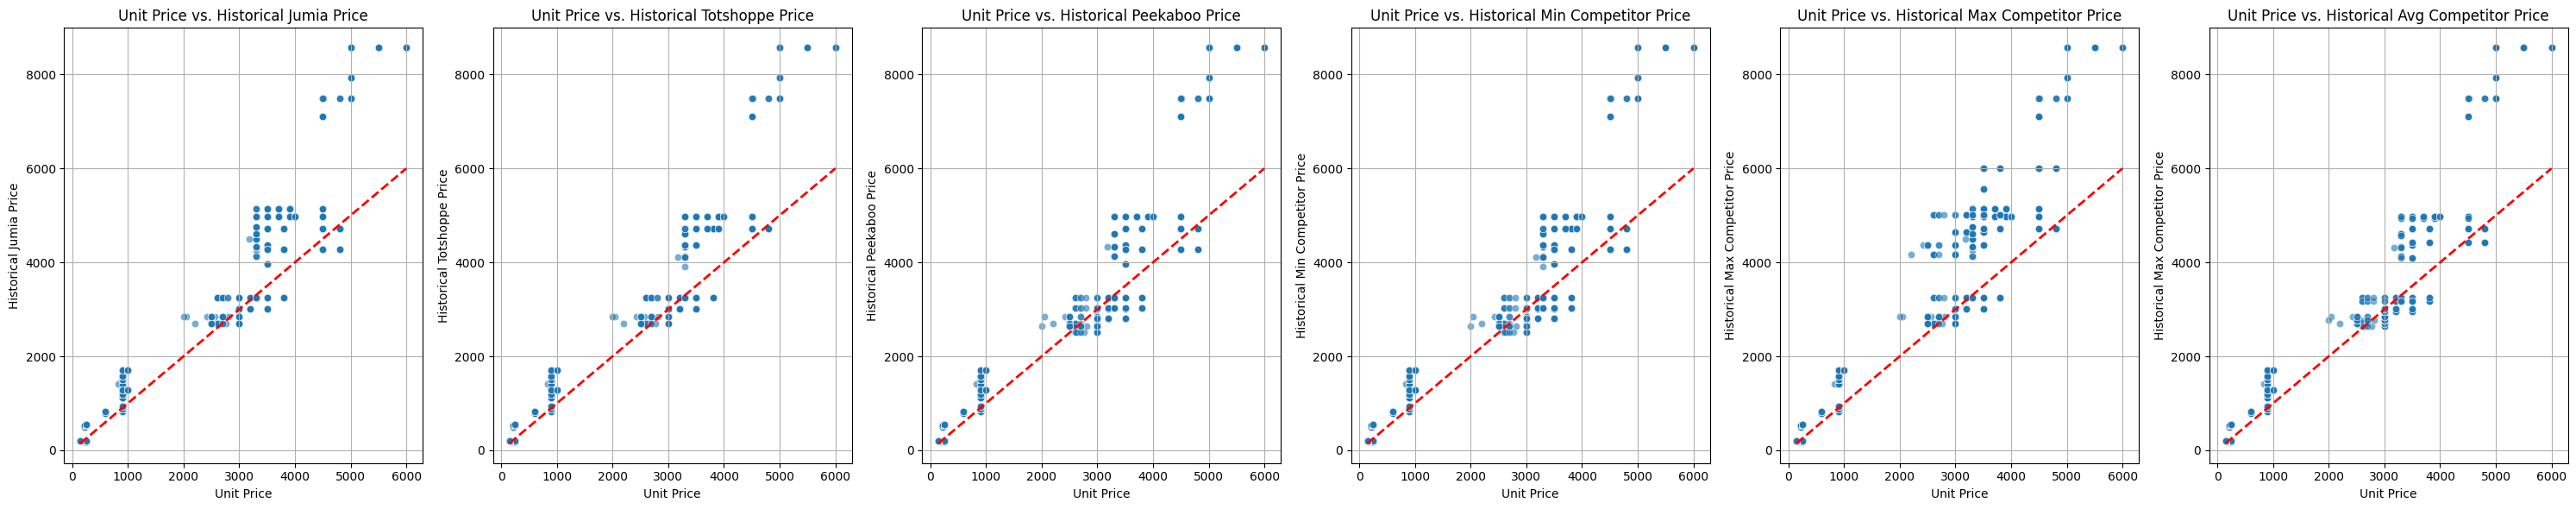

In [1631]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming price_comparison_df is already defined from the previous step
# It contains 'unit_price', 'historical_jumia_price', 'historical_totshoppe_price', 'historical_peekaboo_price'

if not price_comparison_df.empty:
    plt.figure(figsize=(30, 6))

    # Plot for Jumia
    plt.subplot(1, 6, 1)
    sns.scatterplot(x='unit_price', y='historical_jumia_price', data=price_comparison_df, alpha=0.6)
    plt.title('Unit Price vs. Historical Jumia Price')
    plt.xlabel('Unit Price')
    plt.ylabel('Historical Jumia Price')
    plt.grid(True)
    plt.plot([price_comparison_df['unit_price'].min(), price_comparison_df['unit_price'].max()],
             [price_comparison_df['unit_price'].min(), price_comparison_df['unit_price'].max()], 'r--', lw=2)

    # Plot for Totshoppe
    plt.subplot(1, 6, 2)
    sns.scatterplot(x='unit_price', y='historical_totshoppe_price', data=price_comparison_df, alpha=0.6)
    plt.title('Unit Price vs. Historical Totshoppe Price')
    plt.xlabel('Unit Price')
    plt.ylabel('Historical Totshoppe Price')
    plt.grid(True)
    plt.plot([price_comparison_df['unit_price'].min(), price_comparison_df['unit_price'].max()],
             [price_comparison_df['unit_price'].min(), price_comparison_df['unit_price'].max()], 'r--', lw=2)

    # Plot for Peekaboo
    plt.subplot(1, 6, 3)
    sns.scatterplot(x='unit_price', y='historical_peekaboo_price', data=price_comparison_df, alpha=0.6)
    plt.title('Unit Price vs. Historical Peekaboo Price')
    plt.xlabel('Unit Price')
    plt.ylabel('Historical Peekaboo Price')
    plt.grid(True)
    plt.plot([price_comparison_df['unit_price'].min(), price_comparison_df['unit_price'].max()],
             [price_comparison_df['unit_price'].min(), price_comparison_df['unit_price'].max()], 'r--', lw=2)
    
    # plot for Historical Min Competitor Price
    plt.subplot(1, 6, 4)
    sns.scatterplot(x='unit_price', y='historical_min_competitor_price', data=price_comparison_df, alpha=0.6)
    plt.title('Unit Price vs. Historical Min Competitor Price')
    plt.xlabel('Unit Price')
    plt.ylabel('Historical Min Competitor Price')
    plt.grid(True)
    plt.plot([price_comparison_df['unit_price'].min(), price_comparison_df['unit_price'].max()],
             [price_comparison_df['unit_price'].min(), price_comparison_df['unit_price'].max()], 'r--', lw=2)
   
    # plot for Historical Min Competitor Price
    plt.subplot(1, 6, 5)
    sns.scatterplot(x='unit_price', y='historical_max_competitor_price', data=price_comparison_df, alpha=0.6)
    plt.title('Unit Price vs. Historical Max Competitor Price')
    plt.xlabel('Unit Price')
    plt.ylabel('Historical Max Competitor Price')
    plt.grid(True)
    plt.plot([price_comparison_df['unit_price'].min(), price_comparison_df['unit_price'].max()],
             [price_comparison_df['unit_price'].min(), price_comparison_df['unit_price'].max()], 'r--', lw=2)
  

    # plot for Historical Avg Competitor Price
    plt.subplot(1, 6, 6)
    sns.scatterplot(x='unit_price', y='historical_average_competitor_price', data=price_comparison_df, alpha=0.6)
    plt.title('Unit Price vs. Historical Avg Competitor Price')
    plt.xlabel('Unit Price')
    plt.ylabel('Historical Max Competitor Price')
    plt.grid(True)
    plt.plot([price_comparison_df['unit_price'].min(), price_comparison_df['unit_price'].max()],
             [price_comparison_df['unit_price'].min(), price_comparison_df['unit_price'].max()], 'r--', lw=2)
    plt.tight_layout()
    plt.show()
else:
    print("No data to plot for price comparison.")

In [1632]:
df.to_csv('pos_sales_merged_with_competitor.csv', index=False)
#from google.colab import files
#files.download('pos_sales_merged_with_competitor.csv')